## Testing quenching.py

## Import and Preprocess

In [1]:
# ================================
# eLoss-only notebook (pub styling)
# ================================
import numpy as np, matplotlib.pyplot as plt, sys
from dataclasses import replace
sys.path.append("../code")

from glauber import SystemSpec, OpticalGlauber
from quenching import QuenchParams, xA0_from_L, qhat_of_x, _l2, dpt_side
from cross_sections import (SigmaPPTable, sigma_avg_in_bin, RpA_vs_centrality, plot_r_vs_y_in_bins, plot_r_vs_pt_in_bins, average_R,
                            L_eff_minbias)
# your Particle and alpha_s providers:
from particle import Particle              # assumes .d2sigma_pp, .mT, .y_max, .xA, .xB implemented
from coupling import alpha_s_provider      # your running/constant αs factory

## Particle Kinematics & Set up

In [2]:
# 1) Systems & Glauber
roots = 8160.0
spec_pA = SystemSpec(system="pA", roots_GeV=roots, A=208, sigma_nn_mb=71.0)
gl      = OpticalGlauber(spec_pA, verbose=False)

In [3]:
# 2) Particles
P_charmonia = Particle(family="charmonia",  state="avg")     # average charmonia (or "Jpsi", etc.)
P_bottomonia = Particle(family="bottomonia", state="avg")     # average bottomonia (or "Upsilon(1S)", etc.)

In [4]:
# coupling constant provider
alpha_run = alpha_s_provider(mode="running", loops=4, method="ode")
# alpha_cst = alpha_s_provider(mode="constant", alpha0=0.326)
alpha_cst = alpha_s_provider(mode="constant", alpha0=0.50)

alpha_s = alpha_cst

In [5]:
## Quenching parameter setting
qp_base   = QuenchParams(
    qhat0=0.075, lp_fm=1.5,
    LA_fm=L_eff_minbias(gl, "pA"), LB_fm=L_eff_minbias(gl, "pA"),
    lambdaQCD=0.308, roots_GeV=roots,
    alpha_of_mu=alpha_s,
    alpha_scale="mT"   # matches C++
)

In [6]:
# 2) Kinematics quicklook
pt_grid = np.linspace(0.0, 30.0, 121)
print("mT(J/ψ, 10 GeV) =", P_charmonia.mT(10.0))
print("y_max(5.023 TeV, mT=6 GeV) =", P_charmonia.y_max(5023.0, 6.0))

mT(J/ψ, 10 GeV) = 10.571891978260089
y_max(5.023 TeV, mT=6 GeV) = 6.73002317452199


In [7]:
# 4) Optional σ_pp table (big speedup for scans)
import numpy as np
y_tab  = np.linspace(-5.0, 5.0, 41)
pt_tab = np.linspace(0.0,  25.0, 101)
pp_tab_chi = SigmaPPTable(P_charmonia, roots, y_tab, pt_tab)
pp_tab_bot = SigmaPPTable(P_bottomonia, roots, y_tab, pt_tab)

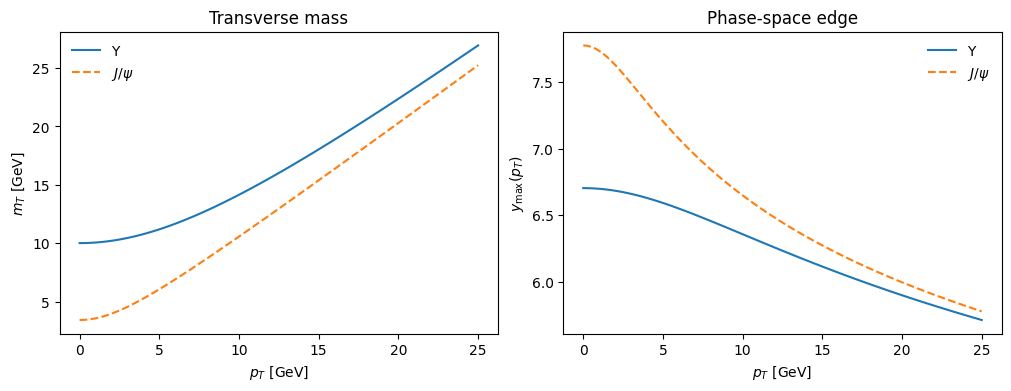

In [8]:
# -------------------------- 1) Kinematics -----------------------------------
fig, ax = plt.subplots(1,2, figsize=(10,3.8), constrained_layout=True)
ax[0].plot(pt_tab, P_bottomonia.mT(pt_tab), label=r"$\Upsilon$")
ax[0].plot(pt_tab, P_charmonia.mT(pt_tab), label=r"$J/\psi$", ls="--")
ax[0].set_xlabel(r"$p_T$ [GeV]"); ax[0].set_ylabel(r"$m_T$ [GeV]")
ax[0].set_title("Transverse mass"); ax[0].legend(frameon=False)

# y_max(pt) for each particle (uses each particle's mass)
ax[1].plot(pt_tab, [P_bottomonia.y_max(roots, P_bottomonia.mT(pt)) for pt in pt_tab], label=r"$\Upsilon$")
ax[1].plot(pt_tab, [P_charmonia.y_max(roots, P_charmonia.mT(pt)) for pt in pt_tab], label=r"$J/\psi$", ls="--")
ax[1].set_xlabel(r"$p_T$ [GeV]"); ax[1].set_ylabel(r"$y_{\max}(p_T)$")
ax[1].set_title("Phase-space edge"); ax[1].legend(frameon=False)
plt.show()

In [9]:
# 5) Define centrality bins (fractions)
cent_edges = (0.0, 0.2, 0.4, 0.6, 0.8, 1.0)   # 0-20-40-60-80-100%

## Glauber Stuffs & $L_{eff}$

In [10]:
# Glauber (pPb @ LHC), then get min-bias L_eff
spec = SystemSpec(system="pA", roots_GeV=8160.0, A=208, sigma_nn_mb=71.0)
gl = OpticalGlauber(spec, verbose=True)
# Min-bias L_eff (optical-style check)
LA_mb = gl.leff_minbias_pA()
print("Min Bias: ", LA_mb)

# For your prints (like the C++ pretty printer)
gl.print_pA_centrality_table([0,100], method="binomial")
gl.print_pA_centrality_table([0,100], method="optical") 

[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7757.76 mb, σ_tot^pA ≈ 1925.90 mb
Min Bias:  10.414158247314315
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: binomial)
--------------------------------------------------------------------------
   0-100%   |       7.748   |    10.394
--------------------------------------------------------------------------
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: optical)
--------------------------------------------------------------------------
   0-100%   |       7.578   |    10.181
--------------------------------------------------------------------------


In [11]:
# Glauber (pPb @ LHC), then get min-bias L_eff
spec = SystemSpec(system="pA", roots_GeV=8160.0, A=208, sigma_nn_mb=71.0)
gl = OpticalGlauber(spec, verbose=True)

# For your prints (like the C++ pretty printer)
gl.print_pA_centrality_table([0,20,40,60,80,100], method="binomial")
gl.print_pA_centrality_table([0,20,40,60,80,100], method="optical") 

[Glauber] TA(r) LUT: A=208 d=0.549 r≤50 fm, dr=0.02, z≤50 fm
[Glauber] ∫T_A d^2x ≈ 208.483 (target A=208)
[Glauber] Tabulating T_AA(b), T_pA(b)…
[Glauber] σ_tot^AA ≈ 7757.76 mb, σ_tot^pA ≈ 1925.90 mb
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: binomial)
--------------------------------------------------------------------------
   0-20 %   |      14.421   |    14.109
  20-40 %   |      11.504   |     9.455
  40-60 %   |       7.684   |     6.217
  60-80 %   |       3.646   |     3.222
  80-100%   |       1.468   |     1.500
--------------------------------------------------------------------------
--------------------------------------------------------------------------
Centrality  |  N_coll(mean)  |  L_eff [fm]   (method: optical)
--------------------------------------------------------------------------
   0-20 %   |      14.206   |    13.305
  20-40 %   |      11.100   |    10.775
  40-60 %   |     

In [12]:
# Grids
pT = np.linspace(0.0, 30.0, 241)
y  = np.linspace(-5.0, 5.0, 201)

# Centrality-binned L_eff using A&P binomial method (Eq. B.9)
bins = [(0,20),(20,40),(40,60),(60,80),(80,100)]
LA_by_bin = gl.leff_bins_pA(bins, rho0_fm3=0.17, Lp_fm=1.5, method="binomial")

# Optical L_Eff
LA_by_bin_opt = gl.leff_bins_pA(bins, method="optical")

## Transport Parameters & Quenching Weights

In [13]:
for LA in LA_by_bin_opt.values():
    print(xA0_from_L(LA))

print("-------------")

for LA in LA_by_bin.values():
    print(xA0_from_L(LA))

0.0079058942361563
0.009761736691539357
0.013744846929504732
0.022632468776218873
0.04304220178075266
-------------
0.007455119724571966
0.011125194310946466
0.01691895830720605
0.032643566441426186
0.07012330504619758


In [14]:
qpar_run = qp_base

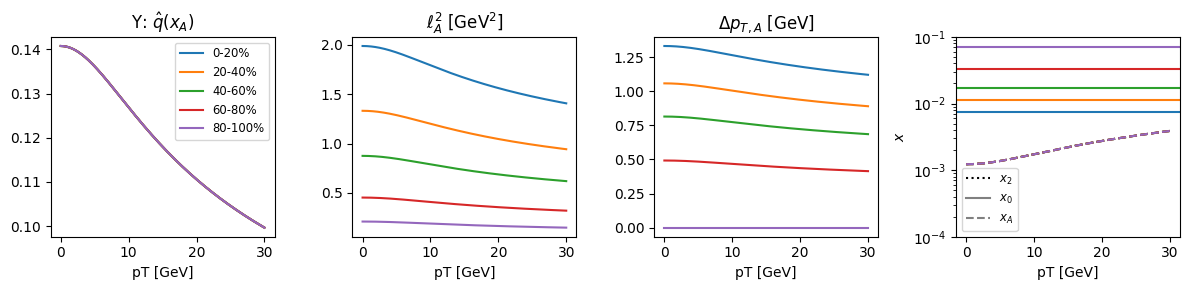

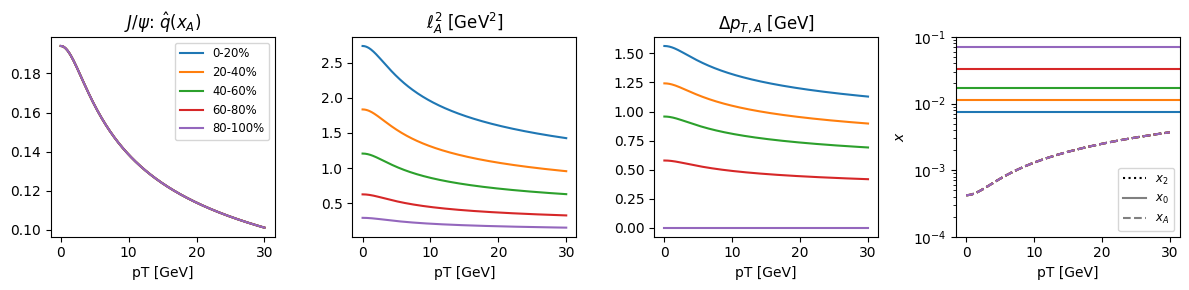

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D # Import this to create custom legend handles

y0 = 0.0
for P, label in [(P_bottomonia, r"$\Upsilon$"), (P_charmonia, r"$J/\psi$")]:
    
    # --- Create 4 subplots ---
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(12, 3))

    # --- Calculate and plot x2 (which is LA-independent) ---
    x2 = P.xA(y0, pT, roots)
    # --- CHANGE 1: Add zorder=1 (background) ---
    ax4.plot(pT, x2, color='black', linestyle=':', label=r'$x_2$', zorder=1) 

    # --- Iterate over the dictionary's items (key, value) ---
    for bin_label, LA in LA_by_bin.items():
        
        # Calculate x0A and the final xA
        x0A = xA0_from_L(LA)
        xA = np.minimum(x2, x0A)
        
        # Calculate other quantities
        l2A = _l2(qpar_run, xA, LA)
        dptA = [dpt_side(qpar_run, xx, LA) for xx in xA]

        # Use the 'bin_label' (e.g., '0-20%') for the legend
        legend_label = bin_label

        # Plot on the first 3 axes (these are correct)
        ax1.plot(pT, qhat_of_x(xA, qpar_run.qhat0), label=legend_label)
        ax2.plot(pT, l2A, label=legend_label)
        ax3.plot(pT, dptA, label=legend_label)
        
        # Get the color
        line_color = ax1.get_lines()[-1].get_color()
        
        # --- CHANGE 2: Add zorder=2 (foreground) to xA ---
        # This will draw the dashed xA line ON TOP of the other lines
        ax4.plot(pT, xA, linestyle='--', color=line_color, zorder=2)
        
        # --- CHANGE 3: Add zorder=1 (background) to x0 ---
        ax4.axhline(x0A, linestyle='-', color=line_color, zorder=1)

    # --- After the inner loop, set titles, labels, and legends ---
    
    # Set titles and x-labels
    ax1.set_title(label + r": $\hat q(x_A)$")
    ax1.set_xlabel("pT [GeV]")
    
    ax2.set_title(r"$\ell_A^2$ [GeV$^2$]")
    ax2.set_xlabel("pT [GeV]")
    
    ax3.set_title(r"$\Delta p_{T,A}$ [GeV]")
    ax3.set_xlabel("pT [GeV]")
    
    # Set title and labels for the new 4th plot
    ax4.set_xlabel("pT [GeV]")
    ax4.set_ylabel(r"$x$")
    ax4.set_ylim(1e-4,1e-1)
    ax4.set_yscale("log") # keep the log scale

    # --- CHANGE 4: Consolidate centrality legend ---
    # Put a 2-column legend on ax1 and remove the others
    ax1.legend(ncol=1, fontsize='small')
    # ax2.legend() # REMOVED
    # ax3.legend() # REMOVED
    
    # --- FIX 4: Create a custom legend for ax4 ---
    # (This was already correct)
    legend_elements = [
        Line2D([0], [0], color='black', linestyle=':', label=r'$x_2$'),
        Line2D([0], [0], color='gray', linestyle='-', label=r'$x_0$'),
        Line2D([0], [0], color='gray', linestyle='--', label=r'$x_A$')
    ]
    ax4.legend(handles=legend_elements, fontsize='small')

    plt.tight_layout()
    plt.show()

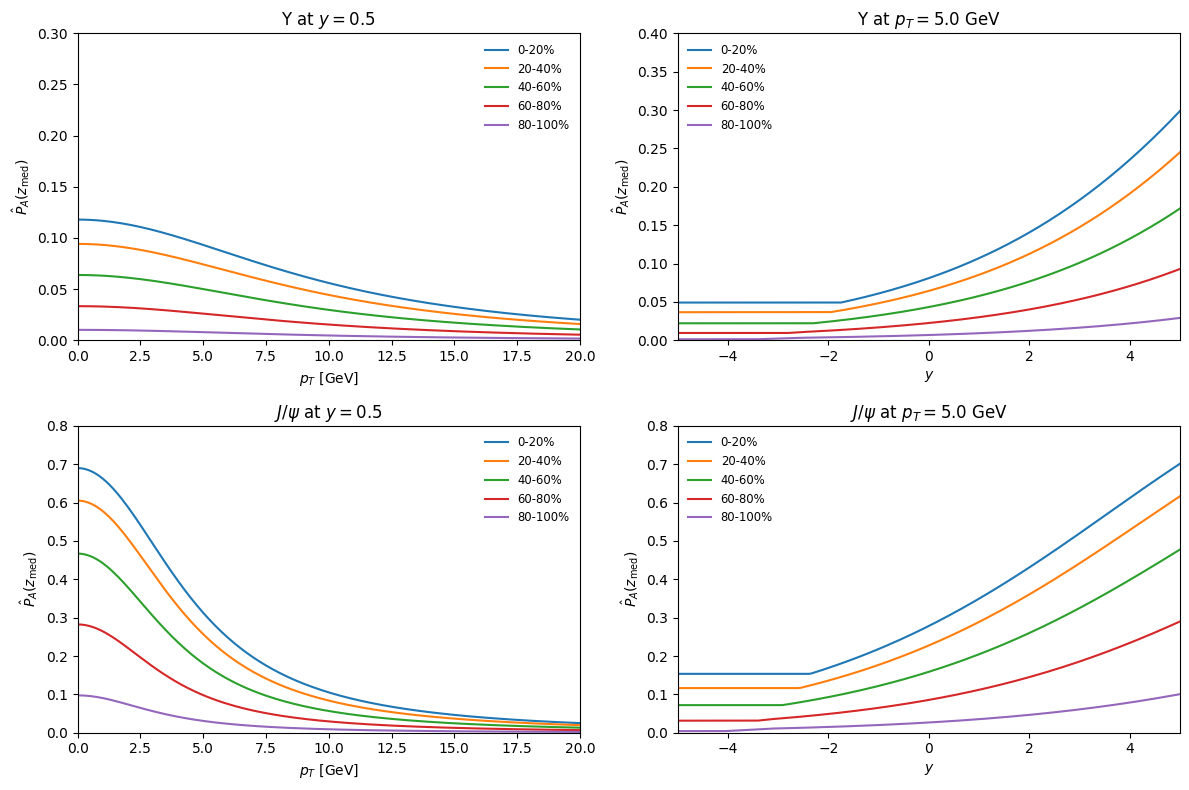

In [16]:
# 2) Quenching-weight diagnostics (median z)
from quenching import diagnostics_row
import matplotlib.pyplot as plt
# 1. Refactored function to plot "vs pT" on a given subplot
def diag_vs_pT_panel(ax, P, y_fix, qpar_base, label, ylim=(0.02,0.5)):
    """Plots median P_A vs pT on a given Axes (ax)."""
    
    # Use the dictionary to get centrality bins and LA values
    for bin_label, L in LA_by_bin_opt.items():
        qp = qpar_base.__class__(**{**qpar_base.__dict__, "LA_fm": L})
        vals = []
        for pt in pT:
            mT = P.mT(pt); ymx = P.y_max(roots, mT)
            xA = min(P.xA(y_fix, pt, roots), xA0_from_L(qp.LA_fm))
            row = diagnostics_row(y=y_fix, pt=pt, mT=mT, xA=xA, xB=xA, y_max_pt=ymx, qpar=qp)
            vals.append(row["PhA_med"])
        
        # Plot on the provided 'ax' using the centrality 'bin_label'
        ax.plot(pT, vals, label=bin_label)
    ax.set_ylim(ylim[0],ylim[1])  
    ax.set_xlim(0,20)  
    ax.set_xlabel(r"$p_T$ [GeV]")
    ax.set_ylabel(r"$\hat P_A(z_{\rm med})$")
    ax.set_title(label + fr" at $y={y_fix}$")
    ax.legend(frameon=False, fontsize='small')


# 2. New function to plot "vs y" on a given subplot
def diag_vs_y_panel(ax, P, pt_fix, qpar_base, label, ylim=(0.02,0.5)):
    """Plots median P_A vs y on a given Axes (ax)."""

    # Use the dictionary
    for bin_label, L in LA_by_bin_opt.items():
        qp = qpar_base.__class__(**{**qpar_base.__dict__, "LA_fm": L})
        vals = []
        for yy in y:
            mT = P.mT(pt_fix); ymx = P.y_max(roots, mT)
            xA = min(P.xA(yy, pt_fix, roots), xA0_from_L(qp.LA_fm))
            row = diagnostics_row(y=yy, pt=pt_fix, mT=mT, xA=xA, xB=xA, y_max_pt=ymx, qpar=qp)
            vals.append(row["PhA_med"])
            
        # Plot on the provided 'ax'
        ax.plot(y, vals, label=bin_label)
    ax.set_ylim(ylim[0],ylim[1])
    ax.set_xlim(-5,5) 
    ax.set_xlabel(r"$y$")
    ax.set_ylabel(r"$\hat P_A(z_{\rm med})$")
    ax.set_title(label + fr" at $p_T={pt_fix}$ GeV")
    ax.legend(frameon=False, fontsize='small')


# --- 3. Main plotting block to create the 2x2 grid ---

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))

# --- Top Row: Upsilon ---
diag_vs_pT_panel(
    ax=axes[0, 0],  # Top-left
    P=P_bottomonia, 
    y_fix=0.5, 
    qpar_base=qpar_run, 
    label=r"$\Upsilon$",
    ylim=(0.0,0.3)
)
diag_vs_y_panel(
    ax=axes[0, 1],  # Top-right
    P=P_bottomonia, 
    pt_fix=5.0, 
    qpar_base=qpar_run, 
    label=r"$\Upsilon$",
    ylim=(0.0,0.4)
)

# --- Bottom Row: J/psi ---
diag_vs_pT_panel(
    ax=axes[1, 0],  # Bottom-left
    P=P_charmonia, 
    y_fix=0.5, 
    qpar_base=qpar_run, 
    label=r"$J/\psi$",
    ylim=(0.0,0.8)
)
diag_vs_y_panel(
    ax=axes[1, 1],  # Bottom-right
    P=P_charmonia, 
    pt_fix=5.0, 
    qpar_base=qpar_run, 
    label=r"$J/\psi$",
    ylim=(0.0,0.80)
)

# Clean up the layout and display the single figure
plt.tight_layout()
plt.show()